
Prac No:04 Extra
Aim : to build and evaluate a decision tree model for classification task and study the effect of tree depth and splitting criteria
Name: Vaishnavi Sandokar USN: CS24D007


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path="/content/drive/MyDrive/ML /Developer_Performance_dataset_1000.csv"
df=pd.read_csv(path)
df.head(5)

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate
0,7,416,9,7,6,5.9,92,7,99,10.5,20,3,34
1,4,269,16,13,5,5.1,85,2,100,9.5,17,8,36
2,11,439,3,0,2,6.2,38,2,55,18.3,35,2,79
3,8,472,15,9,4,4.2,26,5,30,12.6,28,4,94
4,5,265,19,16,5,8.1,82,6,82,7.0,25,9,33


In [ ]:
df.describe()

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate
count,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.84000,356.23400,9.876000,7.153000,2.961000,6.465800,56.933000,3.368000,66.410000,8.700100,17.253000,4.544000,56.578000
std,3.15854,188.15535,5.796052,5.468226,2.021278,1.439529,21.767506,2.342234,21.865452,5.992891,10.836901,2.820997,20.814879
min,1.00000,26.00000,0.000000,0.000000,0.000000,4.000000,20.000000,0.000000,30.000000,0.500000,1.000000,0.000000,30.000000
25%,3.00000,209.50000,5.000000,2.000000,1.000000,5.200000,38.000000,1.000000,48.000000,4.000000,9.000000,2.000000,37.000000
50%,6.00000,332.00000,10.000000,7.000000,3.000000,6.400000,57.000000,3.000000,66.000000,7.450000,14.000000,5.000000,55.500000
75%,9.00000,480.50000,15.000000,12.000000,5.000000,7.700000,76.000000,5.000000,86.000000,12.000000,23.000000,7.000000,74.000000
max,11.00000,993.00000,19.000000,19.000000,6.000000,9.000000,94.000000,7.000000,100.000000,27.500000,50.000000,9.000000,100.000000


In [ ]:
df.shape

(1000, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Hours_Coding         1000 non-null   int64  
 1   Lines_of_Code        1000 non-null   int64  
 2   Bugs_Found           1000 non-null   int64  
 3   Bugs_Fixed           1000 non-null   int64  
 4   AI_Usage_Hours       1000 non-null   int64  
 5   Sleep_Hours          1000 non-null   float64
 6   Cognitive_Load       1000 non-null   int64  
 7   Coffee_Intake        1000 non-null   int64  
 8   Stress_Level         1000 non-null   int64  
 9   Task_Duration_Hours  1000 non-null   float64
 10  Commits              1000 non-null   int64  
 11  Errors               1000 non-null   int64  
 12  Task_Success_Rate    1000 non-null   int64  
dtypes: float64(2), int64(11)
memory usage: 101.7 KB


In [ ]:
df.columns

Index(['Hours_Coding', 'Lines_of_Code', 'Bugs_Found', 'Bugs_Fixed',
       'AI_Usage_Hours', 'Sleep_Hours', 'Cognitive_Load', 'Coffee_Intake',
       'Stress_Level', 'Task_Duration_Hours', 'Commits', 'Errors',
       'Task_Success_Rate'],
      dtype='object')

In [ ]:
df.isnull().any().any()

np.False_

In [ ]:
df.isnull().sum()

,0
Hours_Coding,0
Lines_of_Code,0
Bugs_Found,0
Bugs_Fixed,0
AI_Usage_Hours,0
Sleep_Hours,0
Cognitive_Load,0
Coffee_Intake,0
Stress_Level,0
Task_Duration_Hours,0


In [ ]:
df[df.isnull().any(axis=1)]

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate


In [ ]:
df.columns

Index(['Hours_Coding', 'Lines_of_Code', 'Bugs_Found', 'Bugs_Fixed',
       'AI_Usage_Hours', 'Sleep_Hours', 'Cognitive_Load', 'Coffee_Intake',
       'Stress_Level', 'Task_Duration_Hours', 'Commits', 'Errors',
       'Task_Success_Rate'],
      dtype='object')

In [ ]:
df.shape

(1000, 13)

In [ ]:
before_rows=df.shape[0]
df=df.dropna()
after_rows=df.shape[0]
print('before_rows:',before_rows)
print('after_rows:',after_rows)
print("the number of dropped rows are:", before_rows-after_rows)

before_rows: 1000
after_rows: 1000
the number of dropped rows are: 0


In [ ]:
df.shape

(1000, 13)

In [ ]:
# Count rows before dropping missing values
before_rows = df.shape[0]

# Drop missing values
df = df.dropna()

# Count rows after dropping
after_rows = df.shape[0]

# Print results
print("Rows before dropping:", before_rows)
print("Rows after dropping :", after_rows)
print("Number of dropped rows:", before_rows - after_rows)
print("Percentage dropped: {:.2f}%".format(((before_rows - after_rows) / before_rows) * 100))

Rows before dropping: 1000
Rows after dropping : 1000
Number of dropped rows: 0
Percentage dropped: 0.00%


In [ ]:
print(df.columns)

Index(['Hours_Coding', 'Lines_of_Code', 'Bugs_Found', 'Bugs_Fixed',
       'AI_Usage_Hours', 'Sleep_Hours', 'Cognitive_Load', 'Coffee_Intake',
       'Stress_Level', 'Task_Duration_Hours', 'Commits', 'Errors',
       'Task_Success_Rate'],
      dtype='object')


In [ ]:
clean_data = df.copy()

column_name = 'Task_Success_Rate'  # change this to an existing column name

clean_data['binary_label'] = (
    clean_data[column_name] > clean_data[column_name].median()
).astype(int)

print(clean_data['binary_label'])

0      0
1      0
2      1
3      1
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: binary_label, Length: 1000, dtype: int64


In [ ]:
before_rows = df.shape[0]

df = df.dropna()

after_rows = df.shape[0]

print("Dropped rows:", before_rows - after_rows)

Dropped rows: 0


In [ ]:
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [ ]:
y=clean_data.iloc[:,-1]
print(y)

0      0
1      0
2      1
3      1
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: binary_label, Length: 1000, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
X = clean_data.drop('binary_label', axis=1)
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.7,test_size=0.3,random_state = 42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [ ]:
humidity_classifier=DecisionTreeClassifier(max_leaf_nodes=10,random_state=0)
humidity_classifier.fit(X_train,y_train)

DecisionTreeClassifier(max_leaf_nodes=10, random_state=0)

[Text(0.5, 0.75, 'x[12] <= -0.085\ngini = 0.5\nsamples = 700\nvalue = [344, 356]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 344\nvalue = [344, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 356\nvalue = [0, 356]'),
 Text(0.625, 0.5, '  False')]

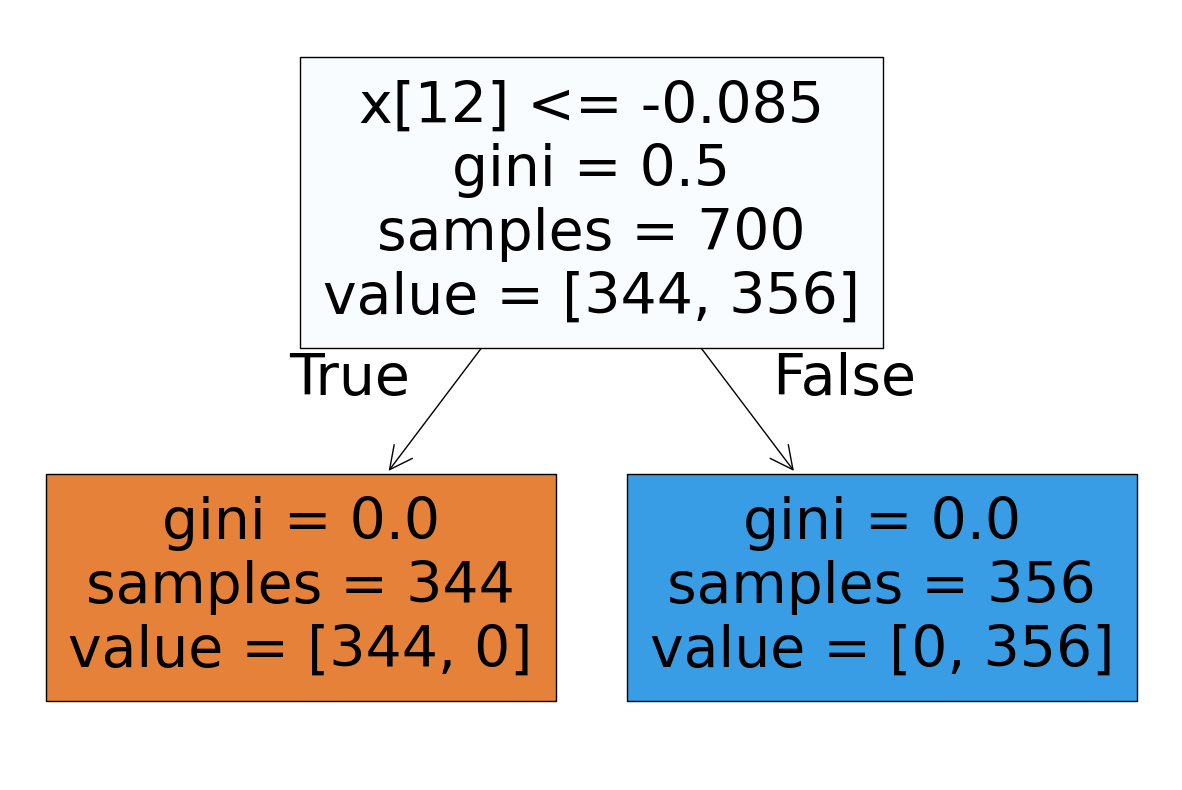

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(humidity_classifier,filled=True)